# K-Nearest Neighbor (KNN) Classification using Iris Dataset

## Objective

The objective of this experiment is to classify Iris flowers using the K-Nearest Neighbor (KNN) algorithm. The model is trained using different values of K (1 to 20), and the accuracy is calculated for each value of K. Finally, Accuracy vs K is plotted to find the best value of K.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Load Iris Dataset
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)

df["Species"] = y


df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
df.shape


(150, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

In [6]:
df["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y
)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Train KNN Model for Different Values of K

In [9]:
accuracy = []

for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracy.append(acc)

In [10]:
for k in range(1, 21):
    print("K =", k, " Accuracy =", accuracy[k-1])

K = 1  Accuracy = 0.9666666666666667
K = 2  Accuracy = 0.9333333333333333
K = 3  Accuracy = 0.9333333333333333
K = 4  Accuracy = 0.9333333333333333
K = 5  Accuracy = 0.9333333333333333
K = 6  Accuracy = 0.9333333333333333
K = 7  Accuracy = 0.9666666666666667
K = 8  Accuracy = 0.9333333333333333
K = 9  Accuracy = 0.9666666666666667
K = 10  Accuracy = 0.9666666666666667
K = 11  Accuracy = 0.9666666666666667
K = 12  Accuracy = 0.9666666666666667
K = 13  Accuracy = 0.9666666666666667
K = 14  Accuracy = 0.9666666666666667
K = 15  Accuracy = 0.9666666666666667
K = 16  Accuracy = 0.9666666666666667
K = 17  Accuracy = 0.9666666666666667
K = 18  Accuracy = 0.9666666666666667
K = 19  Accuracy = 0.9666666666666667
K = 20  Accuracy = 0.9666666666666667


Find the Best Value of K

In [11]:
best_k = np.argmax(accuracy) + 1

print("Best K =", best_k)

print("Highest Accuracy =", max(accuracy))

Best K = 1
Highest Accuracy = 0.9666666666666667


 Plot Accuracy vs K

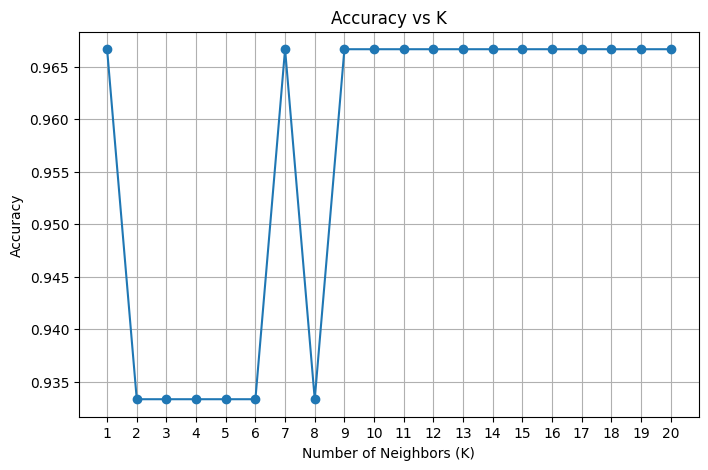

In [12]:
plt.figure(figsize=(8,5))

plt.plot(range(1,21), accuracy, marker='o')

plt.title("Accuracy vs K")

plt.xlabel("Number of Neighbors (K)")

plt.ylabel("Accuracy")

plt.xticks(range(1,21))

plt.grid(True)

plt.show()